In [1]:
import pandas as pd

data = pd.read_csv(r"D:\Envi\post_csv.csv")

print(data.columns)

Index(['ORIG_FID', 'Id', 'class', 'water_po_ms', 'veg_po_mon', 'b1_Bands_1',
       'b2_Bands_1', 'b3_Bands_1', 'b1_Bands_4'],
      dtype='object')


In [5]:
X = data[['water_po_ms', 'veg_po_mon',
          'b1_Bands_1',
          'b2_Bands_1',
          'b3_Bands_1',
          'b1_Bands_4']]

y = data['class']
X = X.fillna(X.mean())
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8416666666666667
Confusion Matrix:
 [[40 15]
 [ 4 61]]
              precision    recall  f1-score   support

           0       0.91      0.73      0.81        55
           1       0.80      0.94      0.87        65

    accuracy                           0.84       120
   macro avg       0.86      0.83      0.84       120
weighted avg       0.85      0.84      0.84       120



In [7]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("\nSVM Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Accuracy: 0.6833333333333333


In [9]:
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=500, random_state=42)
ann.fit(X_train, y_train)

y_pred_ann = ann.predict(X_test)

print("\nANN Accuracy:", accuracy_score(y_test, y_pred_ann))


ANN Accuracy: 0.5416666666666666


In [11]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("\nK-Fold Scores:", scores)
print("Mean Accuracy:", scores.mean())


K-Fold Scores: [0.825     0.95      0.8875    0.875     0.7721519]
Mean Accuracy: 0.8619303797468353


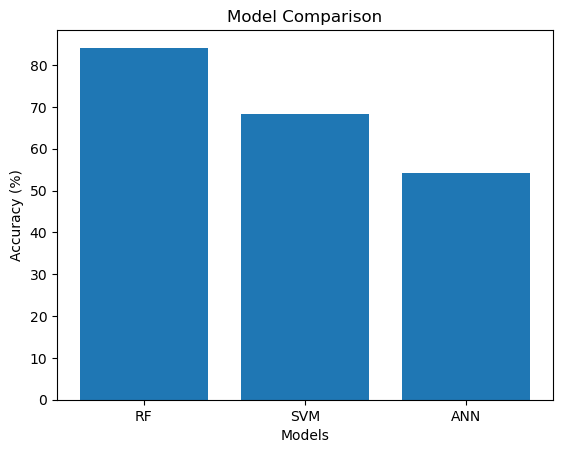

In [13]:
import matplotlib.pyplot as plt

models = ['RF', 'SVM', 'ANN']
accuracy = [84.16, 68.33, 54.16]

plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.show()